In [1]:
import os
import sys
from contextlib import contextmanager, redirect_stdout, redirect_stderr

import tqdm
from tqdm import trange

import numpy as np
import pandas as pd
import torch

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import mannwhitneyu

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import utilities as utils
from scLEMBAS.predict import get_prediction
from scLEMBAS.metrics import distances 

sys.path.insert(1, '../../.')
from McCauley_utils import initialize_mod_and_trainer, all_data

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split

sys.path.insert(1, './.')
from pruning_utils import load_model, get_edge_weights

/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/us

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data

num_stochastic_edges = int(np.round(0.01*sn_ppis.shape[0]))


In [4]:
def compute_degrees(edges, n_nodes=None):
    if n_nodes is None:
        n_nodes = edges.max() + 1
    deg = np.zeros(n_nodes, dtype=int)
    for u, v in zip(edges[0], edges[1]):
        deg[u] += 1
        deg[v] += 1
    return deg


BIN_SIZE = 15
def bin_connectivity(k):
    return (k // BIN_SIZE) * BIN_SIZE


@contextmanager
def suppress_output():
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            yield

def evaluate(edges, 
             baseline,
             mod,
             original_w, 
             train_barcodes, 
             test_barcodes, 
            ):
    w = original_w.clone()
    removed_weights = np.abs(w[edges[0], edges[1]].detach().cpu().numpy())

    w[edges[0], edges[1]] = 0
    mod.signaling_network.weights.data = w
    
    with suppress_output():
        y = get_prediction(
            mod = mod,
            train_cells = train_barcodes,
            test_cells = test_barcodes, 
            tf_adata = tf_adata,
            cat_col = cat_col,
            pert_col = pert_col,
            ctrl_pert = ctrl_pert, 
            counterfactual = 'perturbation', # counterfactual from tests
            cat_counterfactual_map = None,
            remove_type = 'none',
            return_bias = False, 
            max_cells = int(5e3), 
            return_full = False, 
            stim_label_map = None, # special use case for Kang
        )
    aad = mean_absolute_error(y_true = baseline.X, y_pred = y.X)
    
    del y
    utils.clear_memory()
    
    return aad, removed_weights


def get_aad(mod, fold, ensemble_idx, train_barcodes, test_barcodes, seed):

    original_w = mod.signaling_network.weights.data.clone()

    stochastic_edges = mod.signaling_network.added_edges
    true_edges = mod.signaling_network.edge_real_edges

    all_edges = np.concatenate([stochastic_edges, true_edges], axis=1)
    connection = compute_degrees(all_edges, n_nodes=original_w.shape[0])
    max_conn = int(connection.max())

    with suppress_output():
        baseline = get_prediction(
            mod = mod,
            train_cells = train_barcodes,
            test_cells = test_barcodes, 
            tf_adata = tf_adata,
            cat_col = cat_col,
            pert_col = pert_col,
            ctrl_pert = ctrl_pert, 
            counterfactual = 'perturbation', # counterfactual from tests
            cat_counterfactual_map = None,
            remove_type = 'none',
            return_bias = False, 
            max_cells = int(5e3), 
            return_full = False, 
            stim_label_map = None, # special use case for Kang
        )


    all_mae = []
    for k in trange(BIN_SIZE, max_conn + 1,BIN_SIZE):

        k_connectivity = bin_connectivity(k)

        stoch_k, true_K = [], []

        for u, v in zip(stochastic_edges[0], stochastic_edges[1]):
            if (k-BIN_SIZE) <= (connection[u] + connection[v]) // 2 <= k:

                stoch_k.append([u, v])

        for u, v in zip(true_edges[0], true_edges[1]):
            if (k-BIN_SIZE) <=(connection[u] + connection[v]) // 2 <= k:
                true_K.append([u, v])

        if len(stoch_k) == 0:
            continue
        stoch_k = np.array(stoch_k).T
        mae_s, removed_weights_s = evaluate(
            edges = stoch_k, 
            baseline = baseline, 
            mod = mod,
            original_w = original_w, 
            train_barcodes = train_barcodes, 
            test_barcodes = test_barcodes,
        )
        n_edges = len(stoch_k[0])

        all_mae.append(dict(
            model_id = '{}_{}_0'.format(fold, ensemble_idx),
            connectivity = k_connectivity, 
            type='stochastic', 
            MAE=mae_s,
            mean_weight = np.mean(removed_weights_s),
            n_edges=n_edges,
        ))


        if len(true_K) > 0:
            true_k = np.array(true_K).T
    #         maes = []
    #         removed_weights = []
            rng = np.random.default_rng(seed)
            for ti_ in range(10):
                idx = rng.choice(
                    true_k.shape[1],
                    size=stoch_k.shape[1],
                    replace=True,
                )
                mae_t, removed_weights_t = evaluate(
                    edges = true_k[:, idx], 
                    baseline = baseline,
                    mod = mod,
                    original_w = original_w, 
                    train_barcodes = train_barcodes, 
                    test_barcodes = test_barcodes,
                )
    #             maes.append(mae_t)
    #             removed_weights.append(removed_weights_t)

                all_mae.append(dict(
                    model_id = '{}_{}_{}'.format(fold, ensemble_idx, ti_ + 1),
                    connectivity = k_connectivity, 
                    type='true', 
                    MAE=mae_t, #np.mean(maes),
                    mean_weight = np.mean(removed_weights_s), #np.mean(np.concatenate(removed_weights)),
                    n_edges=n_edges,
                ))
    return all_mae

In [5]:
bn_weight_l2 = 0#1e-1 # 1e-4 # 1e-7
bn_weight_l1 = 1e-3 #0

seed_multiplier = 21234

In [18]:
aad_all = []
counter = 0
for fold in range(5):
    
    split = get_split(fold = fold, author = author)

    test_conds = split['test_conds']
    train_barcodes = split['train_barcodes']
    test_barcodes = split['test_barcodes']
    
    ctrl_conds = sorted(set([tc.split('^')[0] + '^' + ctrl_pert for tc in test_conds]))
    ctrl_mask = tf_adata.obs.loc[train_barcodes, 'condition'].isin(ctrl_conds).values
    ctrl_cells = list(np.array(train_barcodes)[ctrl_mask])
    
    
    for ensemble_idx in range(5):
        print('-----------------Iteration: {} of 25-----------------'.format(counter))
        
        curr_seed = seed + ensemble_idx + 1 + (seed_multiplier * ensemble_idx * fold)
        mod, _, _, _ = load_model(fold = fold, ensemble_idx = ensemble_idx, 
                      bn_weight_l2 = bn_weight_l2, bn_weight_l1 = bn_weight_l1,
                      from_trainer = False)
        
        aad_res = get_aad(mod, fold, ensemble_idx, train_barcodes, test_barcodes, seed = curr_seed)
        aad_all += aad_res
        
        counter += 1
        
aad_all = pd.DataFrame(aad_all)
aad_all.to_csv(os.path.join(data_path, 'processed', 'pruning_AAD.csv'))


In [6]:
aad_all = pd.read_csv(os.path.join(data_path, 'processed', 'pruning_AAD.csv'), index_col = 0)

for log_col in ['MAE', 'connectivity', 'mean_weight', 'n_edges']:
    aad_all['log_{}'.format(log_col)] = np.log(aad_all[log_col] + 1e-20) 

Let's very briefly visualize each component separately, to get a sense of the linearity of relationships to AAD:

In [9]:
%matplotlib inline

In [11]:
ncols

3

In [12]:
nrows

3

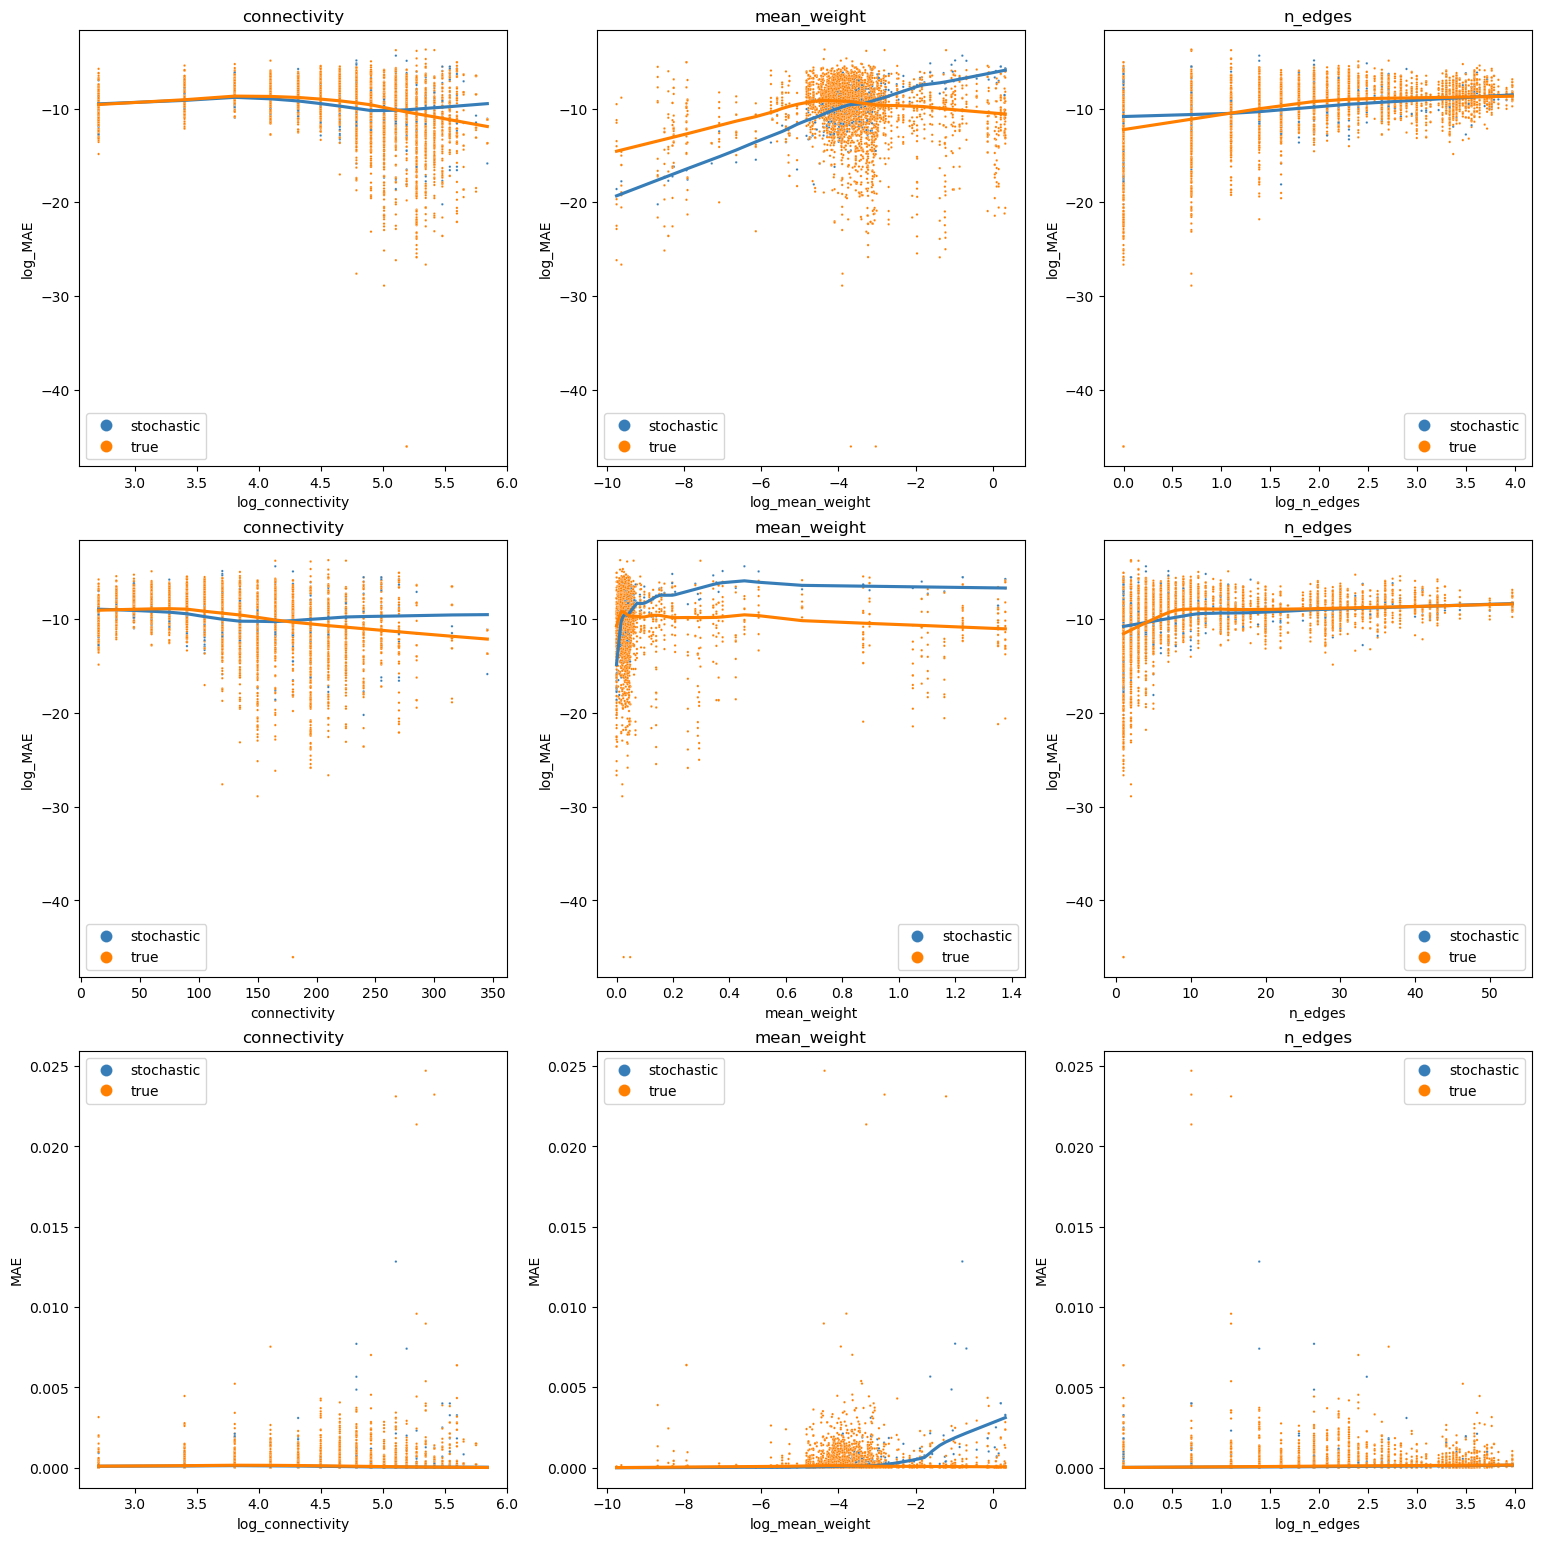

In [13]:
covs = ['connectivity', 'mean_weight', 'n_edges']
axis_types = ['log_both', 'log_y', 'log_x']

ncols = len(covs)
nrows = len(axis_types)


fig, ax = plt.subplots(ncols = ncols,  nrows = nrows, 
                       figsize = (5.1*ncols, nrows*5.1), constrained_layout=True)


types = ['stochastic', 'true']
palette = {
    'stochastic': sns.color_palette('Set1')[1],
    'true': sns.color_palette('Set1')[4],
}


for (i, axis_type) in enumerate(axis_types):
    for (j, cov) in enumerate(covs):


        sns.scatterplot(
            data=aad_all,
            y='MAE' if axis_type == 'log_x' else 'log_MAE',
            x=cov if axis_type == 'log_y' else 'log_{}'.format(cov), # cov
            hue='type',
            hue_order=types,       
            palette=palette,       
            s=3,
            ax=ax[i,j]
        )

        for type_ in types:
            sns.regplot(
                data=aad_all[aad_all.type == type_],
                scatter=False,
                y='MAE' if axis_type == 'log_x' else 'log_MAE',
                x=cov if axis_type == 'log_y' else 'log_{}'.format(cov), # cov
                color=palette[type_],   
                lowess=True,
                ax=ax[i,j]
            )

        ax[i,j].set_title(cov)
        ax[i,j].legend(markerscale=5)

We observe enough non-linearity in the independnet variables that we proceed with a GAMM rather than an OLS to assess effects.

Broadly, we are already seeing a positive relationship between each independent variable and MAE, meaning that each of them plays a orle in model accuracy (MAE being how much the model prediction is effected by each independnet variable when it is removed at that value , relative to baseline of not having removed them).